# Human Activity Recognition Using Hidden Markov Models (HMM)

This notebook implements a complete HMM-based human activity recognition (HAR) pipeline
using smartphone IMU data (accelerometer + gyroscope) for four activities:

| Label | Activity  |
|-------|-----------|
| 0     | Still     |
| 1     | Standing  |
| 2     | Walking   |
| 3     | Jumping   |

**Dataset** — 4 activities × 15 recordings × 2 sensors = 120 CSV files  
**Train** — files 1–12 per activity/sensor (48 samples)  
**Test**  — files 13–15 per activity/sensor (12 samples)


## Section 1: Environment Setup

global constants (activity names, label mapping, train/test file IDs, data path).


In [1]:
# ─────────────────────────────────────────────
# SECTION 1: Environment Setup
# ─────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "hmmlearn", "-q"],
               capture_output=True)

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
np.random.seed(42)
RANDOM_STATE = 42

# ── Activity configuration ──────────────────────────────────────────────────
ACTIVITIES    = ["still", "standing", "walking", "jumping"]
LABEL_MAP     = {a: i for i, a in enumerate(ACTIVITIES)}
INV_LABEL_MAP = {i: a for a, i in LABEL_MAP.items()}

TRAIN_IDS = list(range(1, 13))   # files 1–12
TEST_IDS  = list(range(13, 16))  # files 13–15

DATA_PATH = "/content/drive/MyDrive/ml/markov"

# Column names present in every merged sample
SENSOR_COLS = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]

print("Libraries loaded successfully.")
print(f"  TRAIN IDs : {TRAIN_IDS}")
print(f"  TEST  IDs : {TEST_IDS}")
print(f"  Activities: {ACTIVITIES}")
print(f"  Labels    : {LABEL_MAP}")


Libraries loaded successfully.
  TRAIN IDs : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  TEST  IDs : [13, 14, 15]
  Activities: ['still', 'standing', 'walking', 'jumping']
  Labels    : {'still': 0, 'standing': 1, 'walking': 2, 'jumping': 3}


## Section 2: Data Loading

We mount Google Drive and define helper functions to:

1. **Detect column names** automatically — the files contain `time`, `seconds_elapsed`,
   `x`, `y`, `z` columns which are renamed consistently.
2. **Load** each sensor CSV into a tidy DataFrame.
3. **Merge** accelerometer and gyroscope data per recording using `pandas.merge_asof`
   with `direction='nearest'` to compensate for different sampling rates (~50 Hz vs
   ~100 Hz).
4. Handle **missing values** (forward-fill → backward-fill → drop).


In [2]:
# ─────────────────────────────────────────────
# SECTION 2: Data Loading
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")


def detect_time_column(columns):
    """Return name of the timestamp column (prefers 'time' without 'elapsed')."""
    for c in columns:
        if "time" in c.lower() and "elapsed" not in c.lower():
            return c
    for c in columns:
        if "time" in c.lower():
            return c
    return columns[0]   # last resort


def load_sensor_file(filepath: str, sensor_type: str) -> pd.DataFrame:
    """
    Load one sensor CSV and return a DataFrame with standardised columns:
        [timestamp, {prefix}_x, {prefix}_y, {prefix}_z]

    Parameters
    ----------
    filepath    : path to the CSV file
    sensor_type : 'acc' or 'gyro'
    """
    df = pd.read_csv(filepath)
    df.columns = [c.strip().lower() for c in df.columns]

    time_col = detect_time_column(list(df.columns))
    prefix   = "accel" if "acc" in sensor_type.lower() else "gyro"

    rename_map = {time_col: "timestamp"}
    for c in df.columns:
        lc = c.strip().lower()
        if   lc == "x" or lc.endswith("_x"):  rename_map[c] = f"{prefix}_x"
        elif lc == "y" or lc.endswith("_y"):  rename_map[c] = f"{prefix}_y"
        elif lc == "z" or lc.endswith("_z"):  rename_map[c] = f"{prefix}_z"

    df = df.rename(columns=rename_map)

    keep = ["timestamp"] + [f"{prefix}_{ax}" for ax in ["x", "y", "z"]]
    missing = [c for c in keep if c not in df.columns]
    if missing:
        raise ValueError(f"Columns {missing} not found in {filepath}. "
                         f"Available: {list(df.columns)}")

    df = df[keep].copy()
    df.dropna(subset=["timestamp"], inplace=True)
    df["timestamp"] = df["timestamp"].astype(np.int64)
    df.sort_values("timestamp", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def merge_sensors(acc_df: pd.DataFrame, gyro_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge accelerometer and gyroscope DataFrames by timestamp using merge_asof.

    merge_asof with direction='nearest' matches each accelerometer row to the
    temporally closest gyroscope row, handling different sampling rates cleanly.
    Missing values are forward-filled, then backward-filled, then dropped.
    """
    merged = pd.merge_asof(
        acc_df.sort_values("timestamp"),
        gyro_df.sort_values("timestamp"),
        on="timestamp",
        direction="nearest",
    )
    merged.ffill(inplace=True)
    merged.bfill(inplace=True)
    merged.dropna(inplace=True)
    merged.reset_index(drop=True, inplace=True)
    return merged


def find_file(data_path: str, activity: str, sensor: str, file_id: int):
    """Try common naming conventions; return the first existing path, else None."""
    suffixes = ["acc", "accel"] if sensor == "acc" else ["gyro"]
    for sfx in suffixes:
        p = os.path.join(data_path, f"{activity}_{sfx}_{file_id}.csv")
        if os.path.exists(p):
            return p
    return None


print("Data-loading functions defined.")


Mounted at /content/drive
Data-loading functions defined.


## Section 3: Data Preprocessing

After merging the two sensor streams we:

- **Normalise** all 6 axis signals with `StandardScaler` (zero mean, unit variance).
- **Summarise** the merged and scaled DataFrame (shape, columns, null count, head).


In [3]:
# ─────────────────────────────────────────────
# SECTION 3: Data Preprocessing
# ─────────────────────────────────────────────

def preprocess_merged(df: pd.DataFrame):
    """
    Normalise SENSOR_COLS with StandardScaler.
    Returns (scaled_df, fitted_scaler).
    """
    df = df.copy()
    available = [c for c in SENSOR_COLS if c in df.columns]
    scaler = StandardScaler()
    df[available] = scaler.fit_transform(df[available])
    return df, scaler


def print_summary(df: pd.DataFrame, label: str = "DataFrame"):
    """Print shape, columns, null count, and first 5 rows."""
    bar = "=" * 60
    print(f"\n{bar}")
    print(f"  {label}")
    print(bar)
    print(f"  Shape          : {df.shape}")
    print(f"  Columns        : {list(df.columns)}")
    print(f"  Missing values : {df.isnull().sum().sum()}")
    print("\n  First 5 rows:")
    print(df.head().to_string())
    print(bar + "\n")


print("Preprocessing functions defined.")


Preprocessing functions defined.


## Section 4: Feature Extraction

Each merged recording (one file-pair) is reduced to **one feature vector** by
computing statistics over the entire time window.

| Group | Features | Count |
|-------|----------|-------|
| Time-domain (mean, var, std, SMA) × 6 axes | per axis | 24 |
| Axis correlations (accel x3 + gyro x3) | pairwise Pearson r | 6 |
| Frequency-domain (dom. freq, energy, top-3 FFT mags) × 6 axes | per axis | 30 |
| **Total** | | **60** |

Signal Magnitude Area (SMA): $\text{SMA} = \frac{1}{N}\sum_{i=1}^{N}|x_i|$


In [4]:
# ─────────────────────────────────────────────
# SECTION 4: Feature Extraction
# ─────────────────────────────────────────────

def time_domain_features(signal: np.ndarray, prefix: str) -> dict:
    """Mean, variance, standard deviation, and SMA for a 1-D signal."""
    return {
        f"{prefix}_mean": float(np.mean(signal)),
        f"{prefix}_var" : float(np.var(signal)),
        f"{prefix}_std" : float(np.std(signal)),
        f"{prefix}_sma" : float(np.sum(np.abs(signal)) / len(signal)),
    }


def fft_features(signal: np.ndarray, prefix: str) -> dict:
    """
    Frequency-domain features via FFT:
      - dominant frequency
      - spectral energy  = sum(|X|^2) / N
      - top-3 FFT magnitudes
    """
    N          = len(signal)
    magnitudes = np.abs(fft(signal))[: N // 2]
    freqs      = fftfreq(N, d=1.0)[: N // 2]

    dom_freq        = float(freqs[np.argmax(magnitudes)])
    spectral_energy = float(np.sum(magnitudes ** 2) / N)
    top3_idx        = np.argsort(magnitudes)[-3:][::-1]
    top3_mags       = magnitudes[top3_idx]

    return {
        f"{prefix}_dom_freq"       : dom_freq,
        f"{prefix}_spectral_energy": spectral_energy,
        f"{prefix}_fft_mag1"       : float(top3_mags[0]) if len(top3_mags) > 0 else 0.0,
        f"{prefix}_fft_mag2"       : float(top3_mags[1]) if len(top3_mags) > 1 else 0.0,
        f"{prefix}_fft_mag3"       : float(top3_mags[2]) if len(top3_mags) > 2 else 0.0,
    }


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    """Pearson r; returns 0.0 if either signal is constant or computation fails."""
    try:
        r = float(np.corrcoef(a, b)[0, 1])
        return r if np.isfinite(r) else 0.0
    except Exception:
        return 0.0


def extract_features(df: pd.DataFrame) -> dict:
    """
    Extract all 60 features from a preprocessed merged DataFrame.
    Returns dict mapping feature_name -> float.
    """
    axes = {col: df[col].values for col in SENSOR_COLS if col in df.columns}
    features: dict = {}

    # ── Time-domain (24 features) ─────────────────────────────────────────
    for col, sig in axes.items():
        features.update(time_domain_features(sig, col))

    # ── Axis correlations (6 features) ───────────────────────────────────
    features["corr_accel_xy"] = safe_corr(axes["accel_x"], axes["accel_y"])
    features["corr_accel_xz"] = safe_corr(axes["accel_x"], axes["accel_z"])
    features["corr_accel_yz"] = safe_corr(axes["accel_y"], axes["accel_z"])
    features["corr_gyro_xy"]  = safe_corr(axes["gyro_x"],  axes["gyro_y"])
    features["corr_gyro_xz"]  = safe_corr(axes["gyro_x"],  axes["gyro_z"])
    features["corr_gyro_yz"]  = safe_corr(axes["gyro_y"],  axes["gyro_z"])

    # ── FFT features (30 features) ────────────────────────────────────────
    for col, sig in axes.items():
        features.update(fft_features(sig, col))

    # Guard against any NaN / Inf that slipped through
    for k, v in features.items():
        if not np.isfinite(v):
            features[k] = 0.0

    return features


_dummy_df = pd.DataFrame(
    {col: np.random.randn(100) for col in SENSOR_COLS}
)
_n_feats = len(extract_features(_dummy_df))
print(f"Feature extraction functions defined.")
print(f"  Expected features : 4×6 + 6 + 5×6 = 60")
print(f"  Verified count    : {_n_feats}")
assert _n_feats == 60, f"BUG: expected 60 features, got {_n_feats}"


Feature extraction functions defined.
  Expected features : 4×6 + 6 + 5×6 = 60
  Verified count    : 60



## Section 5: Dataset Construction

We iterate over every `(activity, file_id)` pair and:

1. Locate the accelerometer and gyroscope CSV files.
2. Load, merge, and preprocess them.
3. Extract the 60-feature vector.
4. Collect into `X_train` / `X_test` and generate `y_train` / `y_test`.
5. **Shuffle both splits** before any model training.

| Split | File IDs | Samples per class | Total |
|-------|----------|-------------------|-------|
| Train | 1 – 12   | 12                | 48    |
| Test  | 13 – 15  | 3                 | 12    |



In [ ]:

# ─────────────────────────────────────────────
# SECTION 5: Dataset Construction
# ─────────────────────────────────────────────

def build_dataset(data_path, file_ids, activities, label_map, split_name=""):
    """
    Build feature matrix X and label vector y from all matching CSV files.

    Returns
    -------
    X            : np.ndarray  (n_samples, n_features)
    y            : np.ndarray  (n_samples,)
    feature_names: list[str]
    """
    feature_rows, labels = [], []

    for activity in activities:
        label = label_map[activity]
        for fid in file_ids:
            acc_path  = find_file(data_path, activity, "acc",  fid)
            gyro_path = find_file(data_path, activity, "gyro", fid)

            if acc_path is None or gyro_path is None:
                print(f"  [WARN] {split_name} – missing file: "
                      f"{activity} #{fid} "
                      f"(acc={acc_path is not None}, "
                      f"gyro={gyro_path is not None})")
                continue

            try:
                acc_df  = load_sensor_file(acc_path,  "acc")
                gyro_df = load_sensor_file(gyro_path, "gyro")
                merged  = merge_sensors(acc_df, gyro_df)

                if len(merged) < 5:
                    print(f"  [WARN] {activity} #{fid}: only {len(merged)} rows "
                          f"after merge – skipping.")
                    continue

                merged_scaled, _ = preprocess_merged(merged)
                feats = extract_features(merged_scaled)

                feature_rows.append(feats)
                labels.append(label)

                print(f"  [OK]  {activity:10s} #{fid:2d}  "
                      f"rows={len(merged):5d}  n_feats={len(feats)}")

            except Exception as exc:
                print(f"  [ERROR] {activity} #{fid}: {exc}")

    feat_df = pd.DataFrame(feature_rows)
    X = feat_df.values.astype(np.float64)
    y = np.array(labels, dtype=int)
    return X, y, list(feat_df.columns)


# ── Build TRAIN set ──────────────────────────────────────────────────────
print("=" * 55)
print("  Building TRAINING dataset  (file IDs 1–12) …")
print("=" * 55)
X_train, y_train, feature_names = build_dataset(
    DATA_PATH, TRAIN_IDS, ACTIVITIES, LABEL_MAP, split_name="TRAIN"
)

# ── Build TEST set ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  Building TESTING  dataset  (file IDs 13–15) …")
print("=" * 55)
X_test, y_test, _ = build_dataset(
    DATA_PATH, TEST_IDS, ACTIVITIES, LABEL_MAP, split_name="TEST"
)

rng = np.random.default_rng(RANDOM_STATE)

train_idx = rng.permutation(len(X_train))
X_train, y_train = X_train[train_idx], y_train[train_idx]

test_idx = rng.permutation(len(X_test))
X_test, y_test = X_test[test_idx], y_test[test_idx]

print("\nData shuffled (random_state=42).")

# ── Summary ──────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"  Features: {len(feature_names)}")
print(f"  Train class counts: "
      f"{ dict(zip(*np.unique(y_train, return_counts=True))) }")
print(f"  Test  class counts: "
      f"{ dict(zip(*np.unique(y_test,  return_counts=True))) }")
print(f"\n  Feature names (first 10): {feature_names[:10]}")

feat_peek = pd.DataFrame(X_train[:5], columns=feature_names)
print("\n  First 5 training samples (all 60 features):")
print(feat_peek.to_string())


  Building TRAINING dataset  (file IDs 1–12) …
  [OK]  still      # 1  rows=  514  n_feats=60
  [OK]  still      # 2  rows=  484  n_feats=60
  [OK]  still      # 3  rows=  507  n_feats=60
  [OK]  still      # 4  rows=  526  n_feats=60
  [OK]  still      # 5  rows=  527  n_feats=60
  [OK]  still      # 6  rows=  533  n_feats=60
  [OK]  still      # 7  rows=  532  n_feats=60
  [OK]  still      # 8  rows=  575  n_feats=60
  [OK]  still      # 9  rows=  529  n_feats=60
  [OK]  still      #10  rows=  532  n_feats=60
  [OK]  still      #11  rows=  534  n_feats=60
  [OK]  still      #12  rows=  535  n_feats=60
  [OK]  standing   # 1  rows=  953  n_feats=60
  [OK]  standing   # 2  rows=  963  n_feats=60
  [OK]  standing   # 3  rows=  937  n_feats=60
  [OK]  standing   # 4  rows= 1025  n_feats=60
  [OK]  standing   # 5  rows= 1019  n_feats=60
  [OK]  standing   # 6  rows= 1037  n_feats=60
  [OK]  standing   # 7  rows= 1037  n_feats=60
  [OK]  standing   # 8  rows= 1038  n_feats=60
  [OK]  stand

## Section 6: HMM Model Training

In [6]:
# ─────────────────────────────────────────────
# SECTION 6: HMM Model Training
# ─────────────────────────────────────────────

model = GaussianHMM(
    n_components    = 4,
    covariance_type = "diag",
    n_iter          = 100,
    random_state    = RANDOM_STATE,
    verbose         = False,
)

model.fit(X_train)

print("HMM training complete.")
print(f"  n_components   : {model.n_components}")
print(f"  covariance_type: {model.covariance_type}")
print(f"  Converged      : {model.monitor_.converged}")
print(f"  Log-likelihood (train): {model.score(X_train):.4f}")
print(f"  Log-likelihood (test) : {model.score(X_test):.4f}")

print("\nInitial state distribution π:")
print(np.round(model.startprob_, 4))

print("\nEmission means (first 3 features):")
print(np.round(model.means_[:, :3], 4))

print("\nTransition matrix A:")
print(np.round(model.transmat_, 4))


HMM training complete.
  n_components   : 4
  covariance_type: diag
  Converged      : True
  Log-likelihood (train): -1591.3337
  Log-likelihood (test) : -1053.8053

Initial state distribution π:
[0. 1. 0. 0.]

Emission means (first 3 features):
[[-0.  1.  1.]
 [ 0.  1.  1.]
 [ 0.  1.  1.]
 [-0.  1.  1.]]

Transition matrix A:
[[0.     0.1538 0.4615 0.3846]
 [0.5833 0.0833 0.1667 0.1667]
 [0.3636 0.3636 0.0909 0.1818]
 [0.1818 0.3636 0.1818 0.2727]]


## Section 7: Activity Decoding

In [7]:
# ─────────────────────────────────────────────
# SECTION 7: Activity Decoding
# ─────────────────────────────────────────────

# ── Viterbi decoding ─────────────────────────────────────────────────────
train_states = model.predict(X_train)
test_states  = model.predict(X_test)

print("Decoded state counts:")
print(f"  Train: { dict(zip(*np.unique(train_states, return_counts=True))) }")
print(f"  Test : { dict(zip(*np.unique(test_states,  return_counts=True))) }")

# ── Majority-vote state → label mapping ──────────────────────────────────
print("\nState-to-label mapping (majority vote on training predictions):")
state_to_label: dict = {}

for state in range(model.n_components):
    mask = train_states == state
    if mask.sum() == 0:
        state_to_label[state] = 0
        print(f"  State {state} → (never predicted) → assigned label 0 (still)")
    else:
        candidate_labels = y_train[mask]
        majority = int(stats.mode(candidate_labels, keepdims=True).mode[0])
        state_to_label[state] = majority
        vote_dist = dict(zip(*np.unique(candidate_labels, return_counts=True)))
        vote_dist_named = {
            INV_LABEL_MAP[k]: v for k, v in vote_dist.items()
        }
        print(f"  State {state} → {INV_LABEL_MAP[majority]:10s}  "
              f"(n={mask.sum():2d}, votes={vote_dist_named})")

print(f"\nFinal mapping: {state_to_label}")

# ── Convert decoded states to activity labels ─────────────────────────────
y_pred_train = np.array([state_to_label[s] for s in train_states])
y_pred_test  = np.array([state_to_label[s] for s in test_states])

train_acc = np.mean(y_pred_train == y_train)
test_acc  = np.mean(y_pred_test  == y_test)
print(f"\nTrain accuracy (indicative): {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"Test  accuracy             : {test_acc:.4f}  ({test_acc*100:.2f}%)")

# ── Side-by-side table of true vs predicted labels (test) ────────────────
compare_df = pd.DataFrame({
    "True Label"     : [INV_LABEL_MAP[l] for l in y_test],
    "Predicted Label": [INV_LABEL_MAP[l] for l in y_pred_test],
    "Correct"        : y_pred_test == y_test,
})
print("\nTest predictions (True vs Predicted):")
print(compare_df.to_string(index=False))


Decoded state counts:
  Train: {np.int64(0): np.int64(13), np.int64(1): np.int64(12), np.int64(2): np.int64(11), np.int64(3): np.int64(12)}
  Test : {np.int64(0): np.int64(4), np.int64(1): np.int64(4), np.int64(2): np.int64(2), np.int64(3): np.int64(2)}

State-to-label mapping (majority vote on training predictions):
  State 0 → walking     (n=13, votes={'standing': np.int64(1), 'walking': np.int64(12)})
  State 1 → jumping     (n=12, votes={'jumping': np.int64(12)})
  State 2 → standing    (n=11, votes={'standing': np.int64(11)})
  State 3 → still       (n=12, votes={'still': np.int64(12)})

Final mapping: {0: 2, 1: 3, 2: 1, 3: 0}

Train accuracy (indicative): 0.9792  (97.92%)
Test  accuracy             : 0.8333  (83.33%)

Test predictions (True vs Predicted):
True Label Predicted Label  Correct
     still         jumping    False
   walking         walking     True
   jumping         jumping     True
  standing        standing     True
   walking         walking     True
  standing  

## Section 8: Visualization

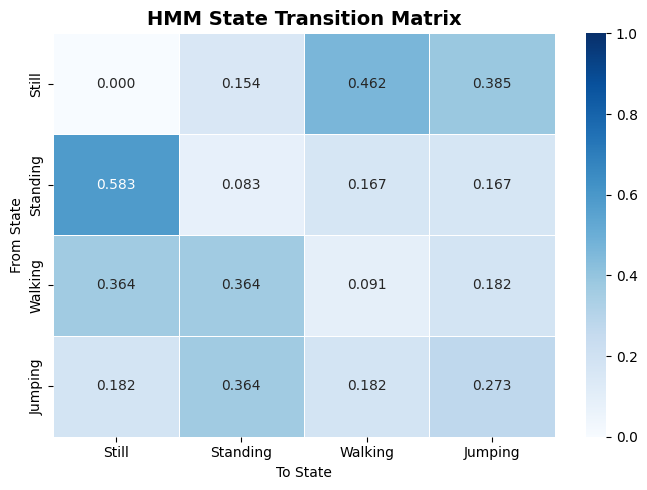

Plot 1 saved: transition_matrix.png


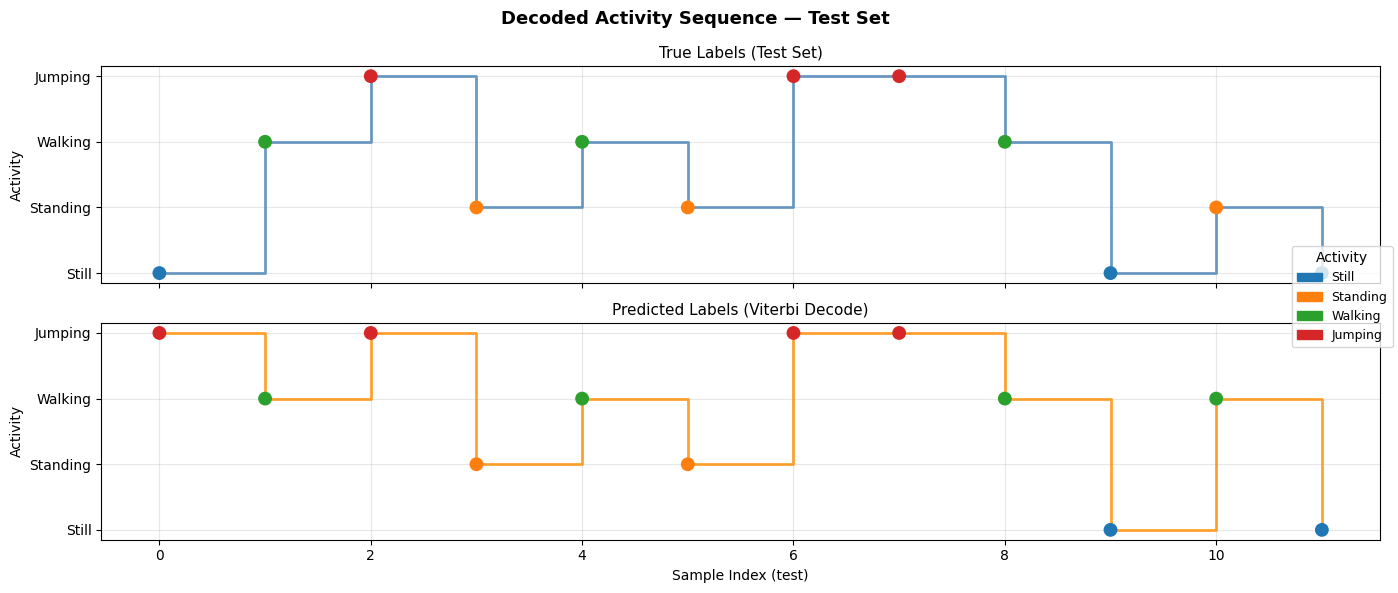

Plot 2 saved: decoded_sequence.png


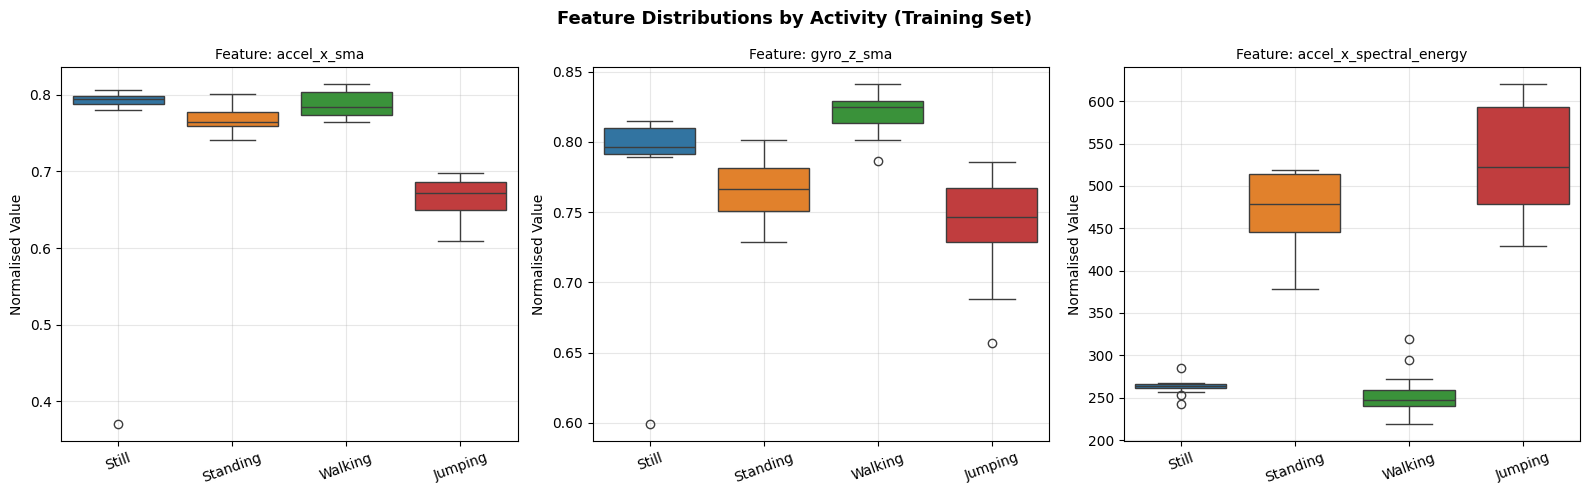

Plot 3 saved: feature_distributions.png


In [8]:
# ─────────────────────────────────────────────
# SECTION 8: Visualization
# ─────────────────────────────────────────────

activity_labels = [INV_LABEL_MAP[i].capitalize() for i in range(4)]
palette         = sns.color_palette("tab10", 4)
color_map       = {i: palette[i] for i in range(4)}

# ── Plot 1: Transition Matrix Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    model.transmat_,
    annot       = True,
    fmt         = ".3f",
    cmap        = "Blues",
    vmin        = 0.0,
    vmax        = 1.0,
    xticklabels = activity_labels,
    yticklabels = activity_labels,
    linewidths  = 0.5,
    ax          = ax,
)
ax.set_title("HMM State Transition Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("To State")
ax.set_ylabel("From State")
plt.tight_layout()
plt.savefig("transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved: transition_matrix.png")

# ── Plot 2: Decoded Activity Sequence (test set) ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
idx = np.arange(len(y_test))

for row_ax, labels_arr, title, color in [
    (axes[0], y_test,      "True Labels (Test Set)",          "steelblue"),
    (axes[1], y_pred_test, "Predicted Labels (Viterbi Decode)", "darkorange"),
]:
    row_ax.step(idx, labels_arr, where="post", color=color, lw=2, alpha=0.8)
    row_ax.scatter(idx, labels_arr,
                   c=[palette[l] for l in labels_arr], s=80, zorder=5)
    row_ax.set_yticks(range(4))
    row_ax.set_yticklabels(activity_labels, fontsize=10)
    row_ax.set_ylabel("Activity")
    row_ax.set_title(title, fontsize=11)
    row_ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Sample Index (test)")
patches = [mpatches.Patch(color=palette[i], label=activity_labels[i])
           for i in range(4)]
fig.legend(handles=patches, loc="center right", title="Activity", fontsize=9)
plt.suptitle("Decoded Activity Sequence — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("decoded_sequence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved: decoded_sequence.png")

# ── Plot 3: Feature Distribution Boxplots ─────────────────────────────────
# Select three informative features across static/dynamic activities
candidate_feats = [
    "accel_x_sma",             # signal magnitude area – high for dynamic activities
    "gyro_z_sma",              # gyro SMA – reveals rotation
    "accel_x_spectral_energy", # FFT energy – high for periodic motion
]
# Fall back to first available features if any are missing
info_features = [f for f in candidate_feats if f in feature_names]
if len(info_features) < 3:
    info_features += [f for f in feature_names if f not in info_features]
info_features = info_features[:3]

feat_df_vis = pd.DataFrame(X_train, columns=feature_names)
feat_df_vis["Activity"] = [INV_LABEL_MAP[l].capitalize() for l in y_train]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ordered_activities = [a.capitalize() for a in ACTIVITIES]

for ax, feat in zip(axes, info_features):
    sns.boxplot(
        data  = feat_df_vis,
        x     = "Activity",
        y     = feat,
        order = ordered_activities,
        palette = "tab10",
        ax    = ax,
    )
    ax.set_title(f"Feature: {feat}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Normalised Value")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, alpha=0.3)

plt.suptitle("Feature Distributions by Activity (Training Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved: feature_distributions.png")


## Section 9: Model Evaluation

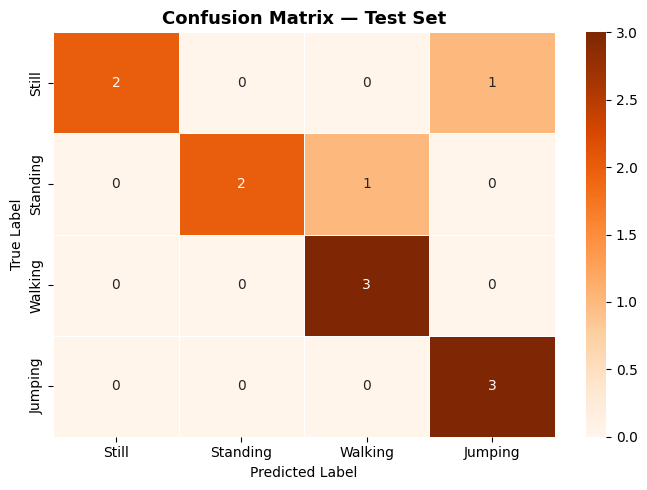

Classification Report (Test Set):
              precision    recall  f1-score   support

       Still       1.00      0.67      0.80         3
    Standing       1.00      0.67      0.80         3
     Walking       0.75      1.00      0.86         3
     Jumping       0.75      1.00      0.86         3

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12

Per-Class Metrics Table:
Activity  TP  FP  FN  TN  Sensitivity  Specificity
   Still   2   0   1   9       0.6667       1.0000
Standing   2   0   1   9       0.6667       1.0000
 Walking   3   1   0   8       1.0000       0.8889
 Jumping   3   1   0   8       1.0000       0.8889

Overall Accuracy : 0.8333  (83.33%)


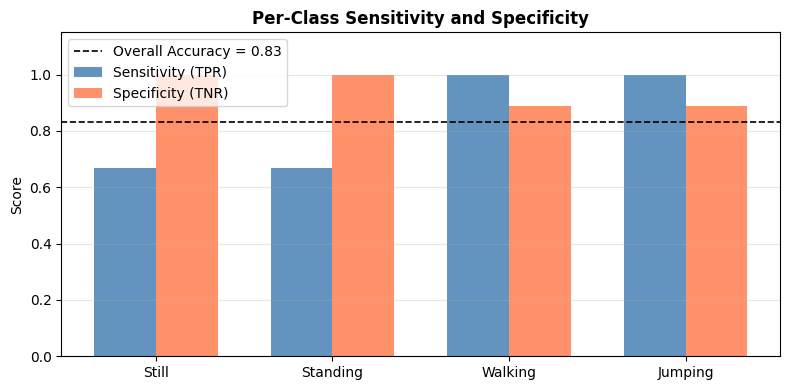

Metrics bar chart saved: sensitivity_specificity.png


In [9]:
# ─────────────────────────────────────────────
# SECTION 9: Model Evaluation
# ─────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred_test, labels=list(range(4)))

# ── Confusion Matrix Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = "d",
    cmap        = "Oranges",
    xticklabels = activity_labels,
    yticklabels = activity_labels,
    linewidths  = 0.5,
    ax          = ax,
)
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Classification Report ────────────────────────────────────────────────
print("Classification Report (Test Set):")
print(classification_report(
    y_test, y_pred_test,
    target_names = activity_labels,
    zero_division = 0,
))

# ── Per-class Sensitivity / Specificity Table ────────────────────────────
def compute_metrics_table(cm: np.ndarray, class_names: list):
    """
    Compute per-class Sensitivity (TPR) and Specificity (TNR).

    For class i:
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP       (missed positives)
        FP = cm[:, i].sum() - TP       (false positives)
        TN = cm.sum() - TP - FP - FN

    Sensitivity = TP / (TP + FN)
    Specificity = TN / (TN + FP)
    """
    rows = []
    for i, name in enumerate(class_names):
        TP = int(cm[i, i])
        FN = int(cm[i, :].sum() - TP)
        FP = int(cm[:, i].sum() - TP)
        TN = int(cm.sum() - TP - FP - FN)
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        rows.append({
            "Activity"   : name,
            "TP"         : TP,
            "FP"         : FP,
            "FN"         : FN,
            "TN"         : TN,
            "Sensitivity": round(sensitivity, 4),
            "Specificity": round(specificity, 4),
        })
    overall_acc = float(cm.diagonal().sum() / cm.sum())
    return pd.DataFrame(rows), overall_acc


metrics_df, overall_acc = compute_metrics_table(cm, activity_labels)

print("Per-Class Metrics Table:")
print(metrics_df.to_string(index=False))
print(f"\nOverall Accuracy : {overall_acc:.4f}  ({overall_acc * 100:.2f}%)")

# ── Bar chart of Sensitivity & Specificity ───────────────────────────────
x   = np.arange(len(activity_labels))
w   = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, metrics_df["Sensitivity"], width=w, label="Sensitivity (TPR)",
       color="steelblue", alpha=0.85)
ax.bar(x + w/2, metrics_df["Specificity"], width=w, label="Specificity (TNR)",
       color="coral",     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(activity_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Per-Class Sensitivity and Specificity", fontsize=12, fontweight="bold")
ax.legend()
ax.axhline(overall_acc, color="black", ls="--", lw=1.2,
           label=f"Overall Accuracy = {overall_acc:.2f}")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("sensitivity_specificity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Metrics bar chart saved: sensitivity_specificity.png")
